# Exploring Mental Health - Ruh Sağlığı Verilerinin Analizi

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR8FtPmfiwlWoHFdcoA1PtSPFwo-v9tGCJZfdARoc5Ppw&s=10">

### Sütun Açıklamaları

**id**: Katılımcıya ait benzersiz kimlik numarası

**Name**: Katılımcının adı

**Gender**: Cinsiyet

**Age**: Yaş

**City**: Yaşadığı şehir

**Working Professional or Student**: Çalışan mı yoksa öğrenci mi olduğu

**Profession**: Mesleği

**Academic Pressure**: Akademik baskı/stres seviyesi

**Work Pressure**: İş baskısı/stres seviyesi

**CGPA**: Genel not ortalaması

**Study Satisfaction**: Eğitim hayatından memnuniyet seviyesi

**Job Satisfaction**: İş hayatından memnuniyet seviyesi

**Sleep Duration**: Günlük uyku süresi

**Dietary Habits**: Beslenme alışkanlıkları

**Degree**: Eğitim derecesi

**Have you ever had suicidal thoughts ?**: Daha önce intihar düşüncesi yaşayıp yaşamadığı

**Work/Study Hours**: Günlük çalışma veya ders çalışma süresi

**Financial Stress**: Finansal stres seviyesi

**Family History of Mental Illness**: Ailede ruhsal hastalık öyküsü olup olmadığı

**Depression**: Depresyon durumu (hedef değişken)

### Veri seti adresi

https://www.kaggle.com/competitions/playground-series-s4e11/data

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s4e11/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e11/train.csv
/kaggle/input/competitions/playground-series-s4e11/test.csv


In [4]:
# Temel Kütüphaneler
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Uyarıları Gizleme
import warnings
warnings.filterwarnings("ignore")

# Ön İşleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Veri Bölme
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Sınıflandırma Modelleri
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Performans Metrikleri
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# CatBoost
from catboost import CatBoostClassifier

In [6]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/playground-series-s4e11
    sample_submission.csv
    train.csv
    test.csv


In [7]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/playground-series-s4e11/sample_submission.csv')

In [9]:
train.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [12]:
train.shape

(140700, 20)

In [13]:
test.shape

(93800, 19)

In [16]:
train.columns

Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [15]:
train.isnull().sum()

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [17]:
train.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [18]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train.select_dtypes(include=['object']).columns

print("Sayısal sütunlar:")
print(numeric_cols)

print("\nKategorik sütunlar:")
print(categorical_cols)

Sayısal sütunlar:
Index(['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress', 'Depression'],
      dtype='object')

Kategorik sütunlar:
Index(['Name', 'Gender', 'City', 'Working Professional or Student',
       'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?',
       'Family History of Mental Illness'],
      dtype='object')


In [19]:
train[['id', 'Depression']].corr()

,id,Depression
id,1.000000,0.003944
Depression,0.003944,1.000000


In [21]:
train.drop('id', axis=1, inplace=True)
test.drop('id', axis=1, inplace=True)

In [23]:
train['Working Professional or Student'].value_counts()

Working Professional or Student
Working Professional    112799
Student                  27901
Name: count, dtype: int64

In [27]:
train['Academic Pressure'].unique()

array([nan,  5.,  2.,  3.,  4.,  1.])

In [30]:
# 1) Öğrenciye özel sütunlar
# Çalışan kişiler için bu alanlar uygulanamaz olduğu için 0 ile dolduruyoruz

train['Academic Pressure'].fillna(0, inplace=True)
train['Study Satisfaction'].fillna(0, inplace=True)

In [31]:
# 2) Çalışanlara özel sütunlar
# Öğrenciler için bu alanlar uygulanamaz olduğu için 0 ile dolduruyoruz

train['Work Pressure'].fillna(0, inplace=True)
train['Job Satisfaction'].fillna(0, inplace=True)

In [32]:
# 3) Az eksik değeri olan kategorik sütunlar
# En sık görülen değer yani mode ile dolduruyoruz

train['Profession'].fillna(train['Profession'].mode()[0], inplace=True)
train['Dietary Habits'].fillna(train['Dietary Habits'].mode()[0], inplace=True)
train['Degree'].fillna(train['Degree'].mode()[0], inplace=True)

In [33]:
# 4) Az eksik değeri olan ordinal/sayısal sütun
# Financial Stress 1-5 arası sıralı bir değer olduğu için median ile dolduruyoruz

train['Financial Stress'].fillna(train['Financial Stress'].median(), inplace=True)

In [34]:

train.isnull().sum()

Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                    0
Academic Pressure                             0
Work Pressure                                 0
CGPA                                     112802
Study Satisfaction                            0
Job Satisfaction                              0
Sleep Duration                                0
Dietary Habits                                0
Degree                                        0
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              0
Family History of Mental Illness              0
Depression                                    0
dtype: int64

In [36]:
train['CGPA'].fillna(0, inplace=True)

In [37]:
train.isnull().sum()

Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [38]:
for col in train.select_dtypes(include='object').columns:
    print(f"{col}: {train[col].nunique()}")

Name: 422
Gender: 2
City: 98
Working Professional or Student: 2
Profession: 64
Sleep Duration: 36
Dietary Habits: 23
Degree: 115
Have you ever had suicidal thoughts ?: 2
Family History of Mental Illness: 2


In [39]:
train.drop('Name', axis=1, inplace=True)

In [40]:
# One-Hot
train = pd.get_dummies(
    train,
    columns=[
        'Gender',
        'Working Professional or Student',
        'Have you ever had suicidal thoughts ?',
        'Family History of Mental Illness'
    ],
    drop_first=True
)

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['City'] = le.fit_transform(train['City'])
train['Profession'] = le.fit_transform(train['Profession'])
train['Sleep Duration'] = le.fit_transform(train['Sleep Duration'])
train['Dietary Habits'] = le.fit_transform(train['Dietary Habits'])
train['Degree'] = le.fit_transform(train['Degree'])

In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 18 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   Age                                                   140700 non-null  float64
 1   City                                                  140700 non-null  int64  
 2   Profession                                            140700 non-null  int64  
 3   Academic Pressure                                     140700 non-null  float64
 4   Work Pressure                                         140700 non-null  float64
 5   CGPA                                                  140700 non-null  float64
 6   Study Satisfaction                                    140700 non-null  float64
 7   Job Satisfaction                                      140700 non-null  float64
 8   Sleep Duration                              

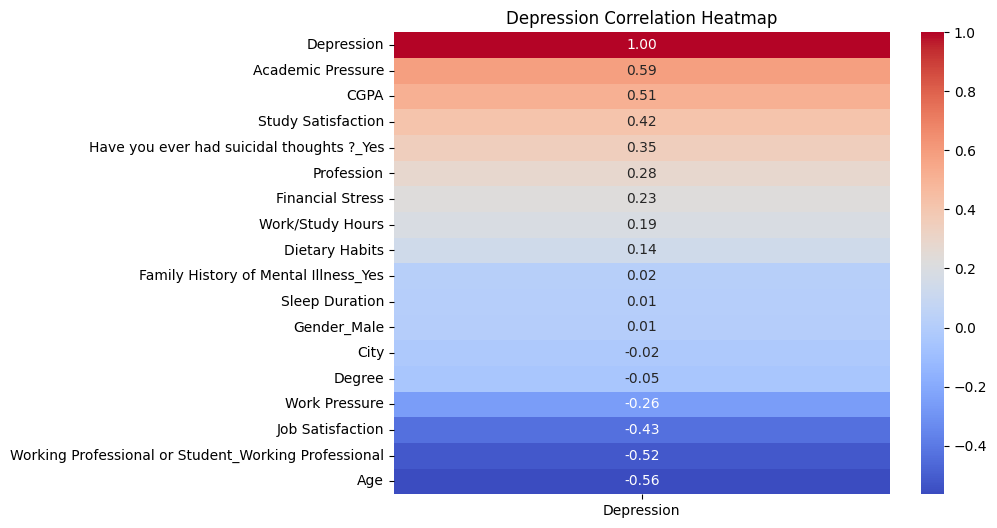

In [53]:
corr = train.corr()['Depression'].sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Depression Correlation Heatmap")
plt.show()

Isı haritası incelendiğinde depresyon ile en yüksek pozitif ilişkinin Academic Pressure, CGPA ve Study Satisfaction değişkenlerinde olduğu görülmektedir. Bu durum, özellikle öğrenciler üzerindeki akademik yükün depresyonla ilişkili olabileceğini göstermektedir. Ayrıca daha önce intihar düşüncesine sahip olmak ve finansal stres düzeyinin yüksek olması da depresyonla pozitif ilişki göstermektedir.

Negatif tarafta ise Age, Working Professional or Student ve Job Satisfaction değişkenleri öne çıkmaktadır. Sonuçlar, yaş arttıkça depresyon görülme eğiliminin azaldığını ve çalışan bireylerde depresyon oranının öğrencilere göre daha düşük olduğunu göstermektedir. Ayrıca iş memnuniyeti arttıkça depresyon görülme olasılığı da azalmaktadır.

Genel olarak sonuçlar, öğrencilerde akademik baskının ve stres faktörlerinin depresyon üzerinde önemli etkileri olduğunu, buna karşılık yaş ve iş memnuniyetinin koruyucu faktörler olarak öne çıktığını göstermektedir.

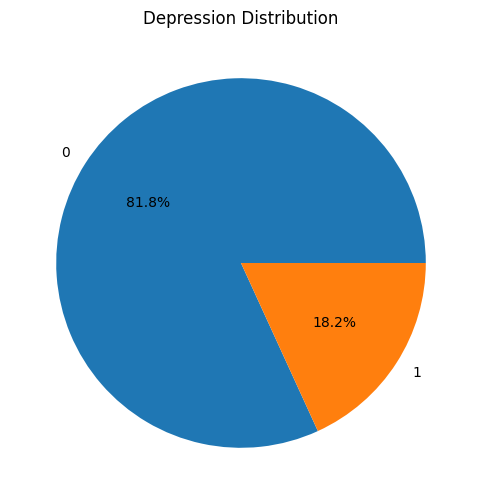

In [54]:
train['Depression'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Depression Distribution')
plt.ylabel('')
plt.show()

Depresyon dağılımı incelendiğinde veri setinin dengesiz bir yapıya sahip olduğu görülmektedir. Katılımcıların %81.8'inde depresyon bulunmazken, %18.2'sinde depresyon bulunmaktadır. Bu durum model değerlendirmelerinde yalnızca doğruluk (Accuracy) metriğinin yeterli olmayabileceğini göstermektedir. Bu nedenle modeller ayrıca Precision, Recall ve F1 Score metrikleri ile de değerlendirilmeli.

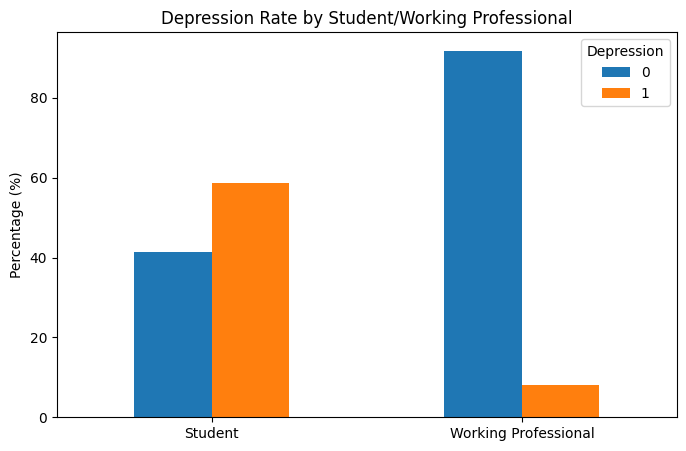

In [58]:
oranlar = (
    train.groupby('Working Professional or Student_Working Professional')['Depression']
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)

oranlar.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Depression Rate by Student/Working Professional')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks([0,1], ['Student', 'Working Professional'], rotation=0)

plt.show()

Öğrenci ve çalışan grupları karşılaştırıldığında, öğrencilerde depresyon görülme oranının çalışanlara göre belirgin şekilde daha yüksek olduğu görülmektedir. Bu durum öğrencilerin depresyon açısından daha hassas bir grup olduğunu göstermektedir.

In [43]:
x = train.drop('Depression', axis=1)
y = train['Depression']

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(112560, 17)
(28140, 17)
(112560,)
(28140,)


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9375621890547263


In [47]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9029140014214642


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9353944562899786


In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()

knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8885216773276475


In [50]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9374911158493248


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd

def algo_test(x, y):

    models = [
        LogisticRegression(max_iter=1000),
        DecisionTreeClassifier(random_state=42),
        RandomForestClassifier(random_state=42),
        KNeighborsClassifier(),
        XGBClassifier(random_state=42, eval_metric='logloss')
    ]

    model_names = [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ]

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    results = []

    for name, model in zip(model_names, models):
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1 Score": f1_score(y_test, y_pred, average="weighted")
        })

    return pd.DataFrame(results).sort_values("F1 Score", ascending=False)

In [52]:
algo_test(x, y)

,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.937491,0.936820,0.937491,0.937110
0,Logistic Regression,0.937562,0.936604,0.937562,0.936976
2,Random Forest,0.935394,0.934144,0.935394,0.934579
1,Decision Tree,0.902914,0.903228,0.902914,0.903068
3,KNN,0.888522,0.887767,0.888522,0.888131


## Sonuç

Yapılan model karşılaştırmaları sonucunda en yüksek performans XGBoost modeli tarafından elde edilmiştir (F1 Score = 0.9371). Logistic Regression modeli de benzer başarı göstermiştir. Elde edilen sonuçlar, depresyon tahmini probleminde boosting tabanlı ve doğrusal sınıflandırma modellerinin oldukça etkili olduğunu göstermektedir.